# Introduction to Single-Cell RNA-seq Analysis

In this assignment you will perform a complete single-cell RNA-seq analysis pipeline:
quality control, cell filtering, dimensionality reduction, clustering, manual annotation,
and differential expression testing.

## Resources
- 📖 **Scanpy tutorials** (easy-to-follow guide): https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html
- 📖 **Single-Cell Best Practices** (more verbose explanation of each step): https://www.sc-best-practices.org/
- 📖 **Scanpy documentation** (API): https://scanpy.readthedocs.io/

## Submission

At the end of the assignment you will export two files:

1. `obs.tsv` — the cell-level metadata table (tab-separated), which **must** contain a column called `manual_celltype_labels`.
2. A CSV file with your differential expression results.
3. Your AnnData object saved as `<filename>_qc.h5ad` (not committed — too large for GitHub).

Only `obs.tsv` and the DE results CSV should be committed to the repository.

> **Note:** Do **not** commit `.h5ad`, `.h5`, or other large binary files. They are excluded by `.gitignore`.

---

## 0 — Imports

Import the libraries you will need. At minimum you will need `scanpy`, `anndata`, `pandas`, `numpy`, and `matplotlib`.


In [1]:
import scanpy as sc
import anndata  as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1 — Load Data

Load the test AnnData object provided in the `data/` folder. Note, for tutorial purposes, a downsampled anndata object is used in this notebook.
The dataset comes from a BD rhapsody experiment, where PBMC from a healthy donor were sequenced. For verification purposes, the annotation is provided in the dataset.

> **Hint:** Use `sc.read_h5ad()` or `anndata.read_h5ad()`.  
> See: https://anndata.readthedocs.io/en/latest/generated/anndata.read_h5ad.html

After loading, inspect the object — check `.obs`, `.var`, `.X`, and `.uns` to understand the data.

In [2]:
adata = sc.read_h5ad('data/unprocessed.h5ad')

We need to first clean up the object a little bit:

In [3]:
# remove genes which don't have a gene name (Unless you are interested in specific genes!)
# ~ (the tilda) negates the selection (it reverses True and False)
adata = adata[:, ~adata.var.gene_symbol.isna()].copy()
# Make sure that the gene symbol column is indeed a string
adata.var['gene_symbol'] = adata.var['gene_symbol'].astype(str)
# Make the gene column the index (nicer plotting, etc)
adata.var = adata.var.set_index('gene_symbol')
# make sure the index is unique
adata.var_names_make_unique()

/tmp/ipykernel_321155/2982049549.py:9: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  adata.var_names_make_unique()


## 2 — Quality Control (QC)

Calculate and visualize standard QC metrics:

- **Total counts** per cell (`total_counts`)
- **Number of detected genes** per cell (`n_genes_by_counts`)
- **Mitochondrial content** — percentage of counts from mitochondrial genes (`pct_counts_mt`)  
  Mitochondrial gene names typically start with `"MT-"` (human) or `"mt-"` (mouse).
- **Ribosomal content** — percentage of counts from ribosomal protein genes (`pct_counts_ribo`)  
  Ribosomal gene names typically start with `"RPS"` or `"RPL"` (human).

> **Hint:** 
> See: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.calculate_qc_metrics.html

Plot the distributions using `sc.pl.violin()` or a scatter plot.  
Refer to the [Best Practices quality control chapter](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html) for guidance on thresholds.

We compute mitochondrial percentage, the ribosomal content and hemoglobin contamination

In [4]:
# mitochondrial genes
adata.var["mt"] =adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains(r"^HB[ABDEGMQZ]\d*(?!\w)")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

Unless we are interested in mitochondrial genes specifically, we want them to be below 10% of the total counts. Higher mitchondrial percentages indicate that the cells are dying or stressed. High ribosomal content is also an indicators of potentially low sample quality. It can also indicate high transcriptional activity. Generally speaking QC always needs to be performed keeping the biology under investigation in mind.

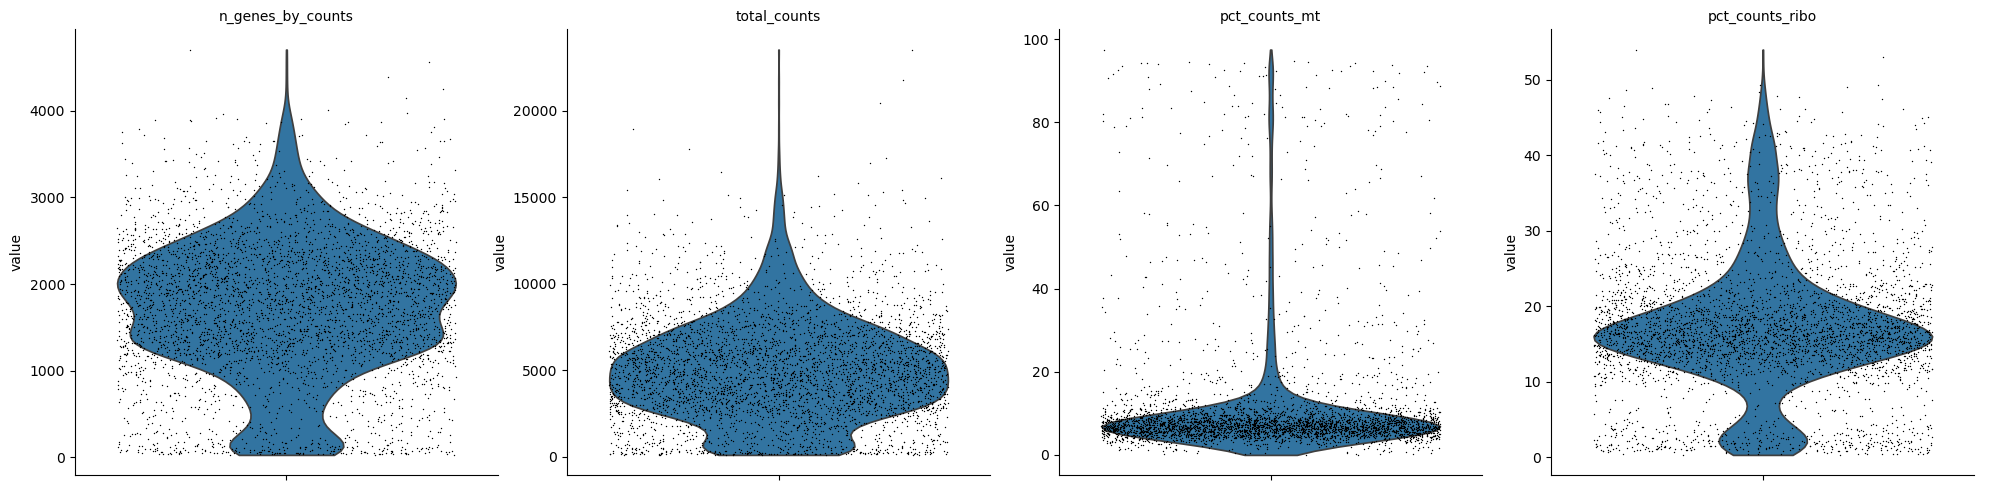

In [5]:

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)


## 3 — Cell & Gene Filtering

Based on your QC plots, define thresholds to remove:

- Low-quality cells (too few counts or too few genes detected)
- Potential doublets or damaged cells (too many counts or very high mitochondrial content)
- Genes that are detected in very few cells

> **Hints:**   
> - Boolean indexing on `adata.obs` also works for more complex filters  
> See: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.filter_cells.html  
> See: https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html#filtering

Print the number of cells and genes before and after filtering.

Some cells may have excessive counts, we can consider removing them.

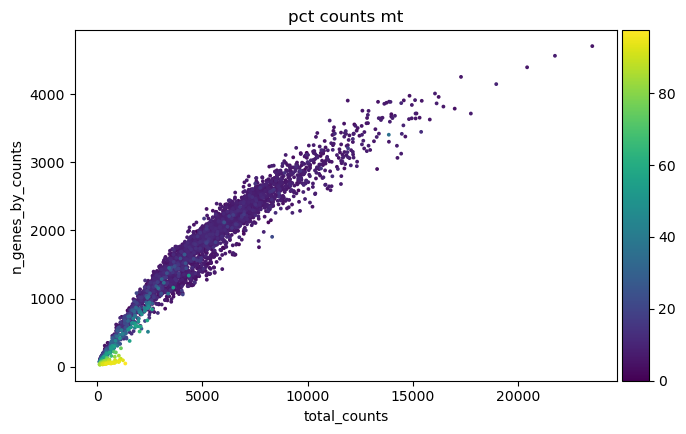

In [6]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

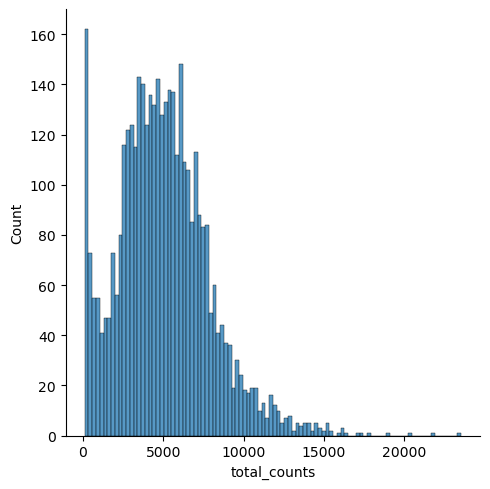

In [7]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)


### 3.2. Cell filtering
Use standard filtering to remove cells with low quality. These filters are somewhat arbitrary and just remove the 'worst' offenders. Depending on your question you can consider setting stricter filtering criteria.

In [8]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

Filter out the cells with an excessive mitochondrial content computed in step 1. 10% is a good number, if you observe generally good quality of the cells you can also go lower. Single-nuclei sequencing (where the nuclei are isolated instead of the whole cells) can have lower numbers.

In [9]:
adata = adata[adata.obs['pct_counts_mt']<10, :].copy()

We can also filter genes with too many reads and too few reads to avoid the tails of the distribution and remove cells which may distort the analysis.

In [10]:
adata = adata[adata.obs['total_counts']<10000, :].copy()
adata = adata[adata.obs['total_counts']>1000, :].copy()

### 3.3. Doublet detection
Doublets are barcodes (droplets) which have more than one cell inside. This can result in weird 'cells'. We only want single cells, so we flag them and we remove them. There are many doublet removal methods.

In [11]:
sc.pp.scrublet(adata)

Remove the doublets which are above a threshold. Looking into the obs column of the data, you will observe that there is also a doublet score. To decide whether a barcode is a doublet or not, a threshold is applied to get a boolean variable.

In [12]:
adata = adata[~adata.obs['predicted_doublet'], :].copy()

### Ambient RNA removal (not shown)
In the droplets you also may find ambient RNA of lysed cells that is present in the sample preparation. You can remove this using other software, e.g. SoupX. It is not done here, but more info is in the single-cell best practices book. 

## 4 — Normalization & Feature Selection

Normalize library size, log-transform, and identify highly variable genes.

> **Hints:**   
> See: https://www.sc-best-practices.org/preprocessing_visualization/normalization.html

In order to store the raw data, we can use the layer feature of the adata object. (Note the .raw slot used in older implementations is deprecated.)

In [13]:
# Saving count data making a deep copy.
adata.layers["counts"] = adata.X.copy()

### 4.1 Normalization
We normalize the data to uniform read depth to make the cells comparable with each other. The method shown below is pretty standard in bulk sequencing. Setting None, will use a different scaling method, you can also set a different sum if required by some tool. The logarithm is applied using a pseudocount of 1, where 1 is added to every entry of the matrix to keep 0 in the empty cells after the logarithm.

In [14]:
sc.pp.normalize_total(adata, target_sum=10000)
sc.pp.log1p(adata)


### 4.2. Feature selection

Select the highly variable genes (other sources choose 'highly deviant' ones. Here we use a particular version, which expects the raw counts, so we specify which layer we want to use for the computation of the data. You can set a higher number of genes, if your ressources allow it. Often, the other genes are still used in downstream analyses, and the highly variable ones are used for the computation of the low dimensional embedding only.

In [15]:

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3', layer='counts')

## 5 — Dimensionality Reduction & Clustering

Reduce the dimensionality of the data, build a neighborhood graph, and cluster the cells. 

> See: https://www.sc-best-practices.org/preprocessing_visualization/dimensionality_reduction.html  
> See: https://www.sc-best-practices.org/preprocessing_visualization/clustering.html

Visualize the UMAP colored by Leiden cluster labels using `sc.pl.umap()`.

### 5.1 Dimensionality reduction
PCA is a linear dimensionality reduction technique which creates a low dimensional representation of the data where each component corresponds to an axis of variation. The neighbours function creates a k-nearest-neighbour graph, which is used in the UMAP and the leiden algorithm to compute the low dimensional representation of the data and the clustering. Note that the graph is clustered and not the UMAP, so the order of those functions does not matter. The resolution of the leiden paramter determines how fine grained the clustering is. A low number creates bigger clusters and a high number more smaller clusters.

In [16]:
sc.pp.pca(adata, n_comps=50) # k = n_comps
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2, directed=False, resolution = 0.1)


/home/bionets-og86asub/Documents/teaching/compbiol-course/compbiol/htseq/1-intro-rnaseq/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 5.2. Clustering & Visualization of the clusters
Show the leiden groups we computed

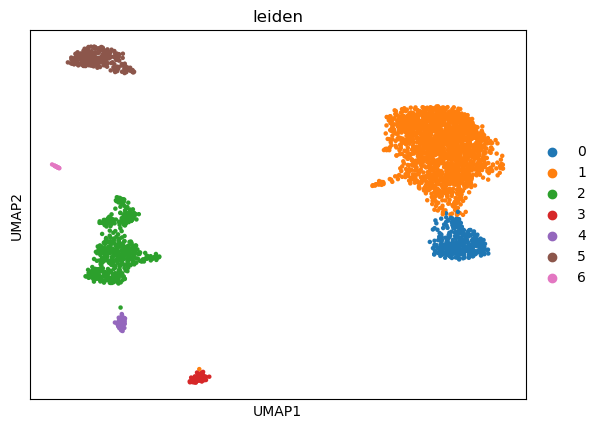

In [17]:
sc.pl.umap(adata, color = ['leiden'])

## 6 — Marker Gene Visualization
What is a 'marker gene'?
Visualize known marker genes on the UMAP to help you identify cell types. The marker genes are representative genes which we know are highly specific for a cell type. Sometimes combinations of markers can be used to specify a cell type.

> **Hints:**  
> You can find markers for the cell types in this tutorial here: https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html
> See: https://www.sc-best-practices.org/cellular_structure/annotation.html
> 

In [18]:
# keys: cell types or populations, values: lists of marker genes
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"]
}

Here we use two marker genes to find two types of macrophages. CD14+ macrophages express CD14. We can see that FCN1 is not specific for CD14+ macropages, as all macrophages exhibit high expression if FCN1, however CD14 is only expressed in a specific cluster, so we can determine that the leiden cluster corresponding to the CD14 positive cluster likely corresponds to this cell type. We do this iteratively for all cell types until we are satisfied with the cluster assignments. Some marker genes are not very specific.


We can store the labels in a new column called **`manual_celltype_labels`** in `adata.obs`.

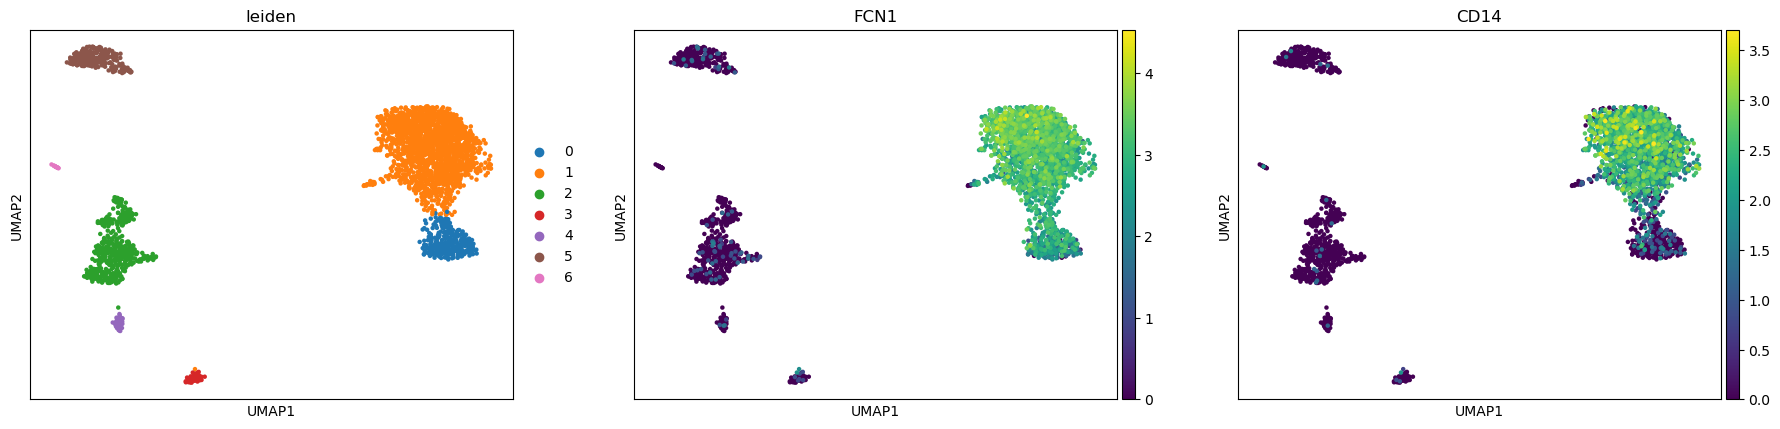

In [19]:
sc.pl.umap(adata, color = ['leiden'] + marker_genes['CD14+ Mono'])

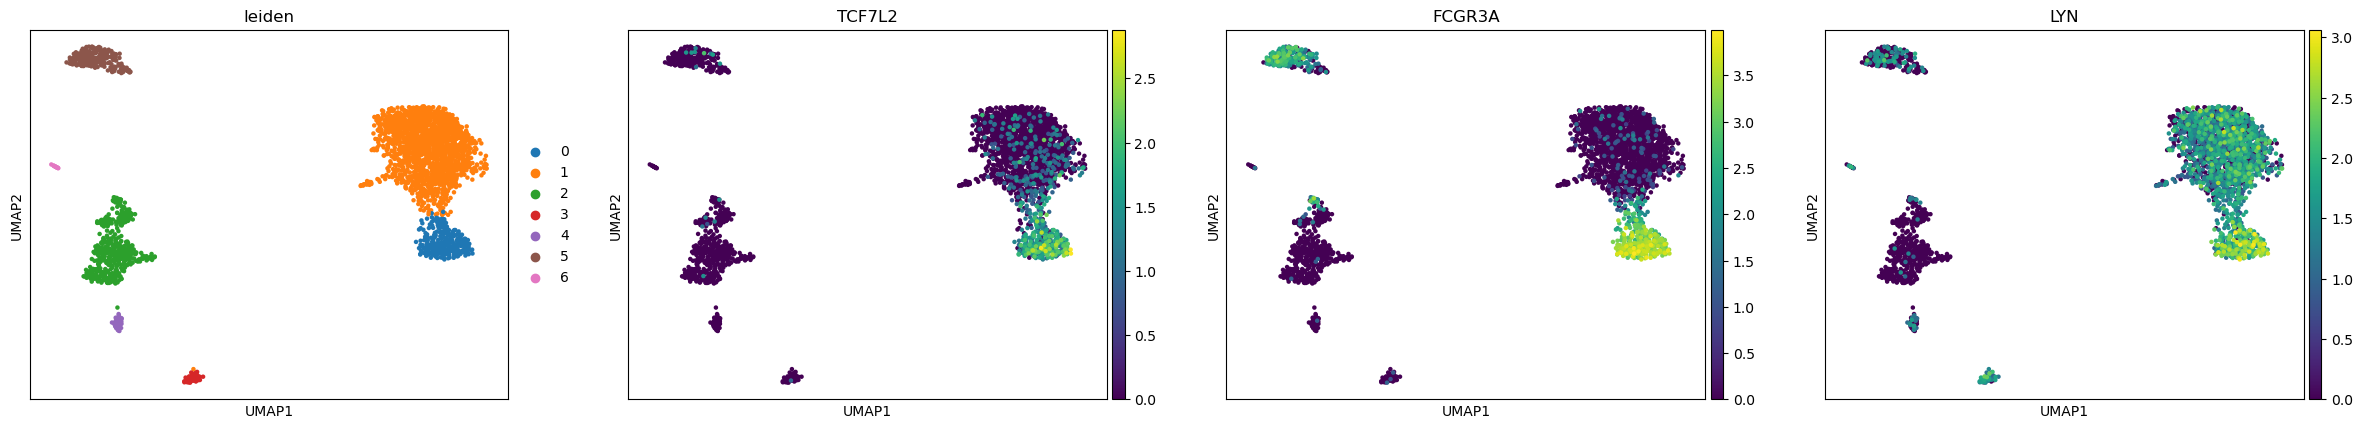

In [20]:
sc.pl.umap(adata, color =  ['leiden'] +marker_genes['CD16+ Mono'])

In [21]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

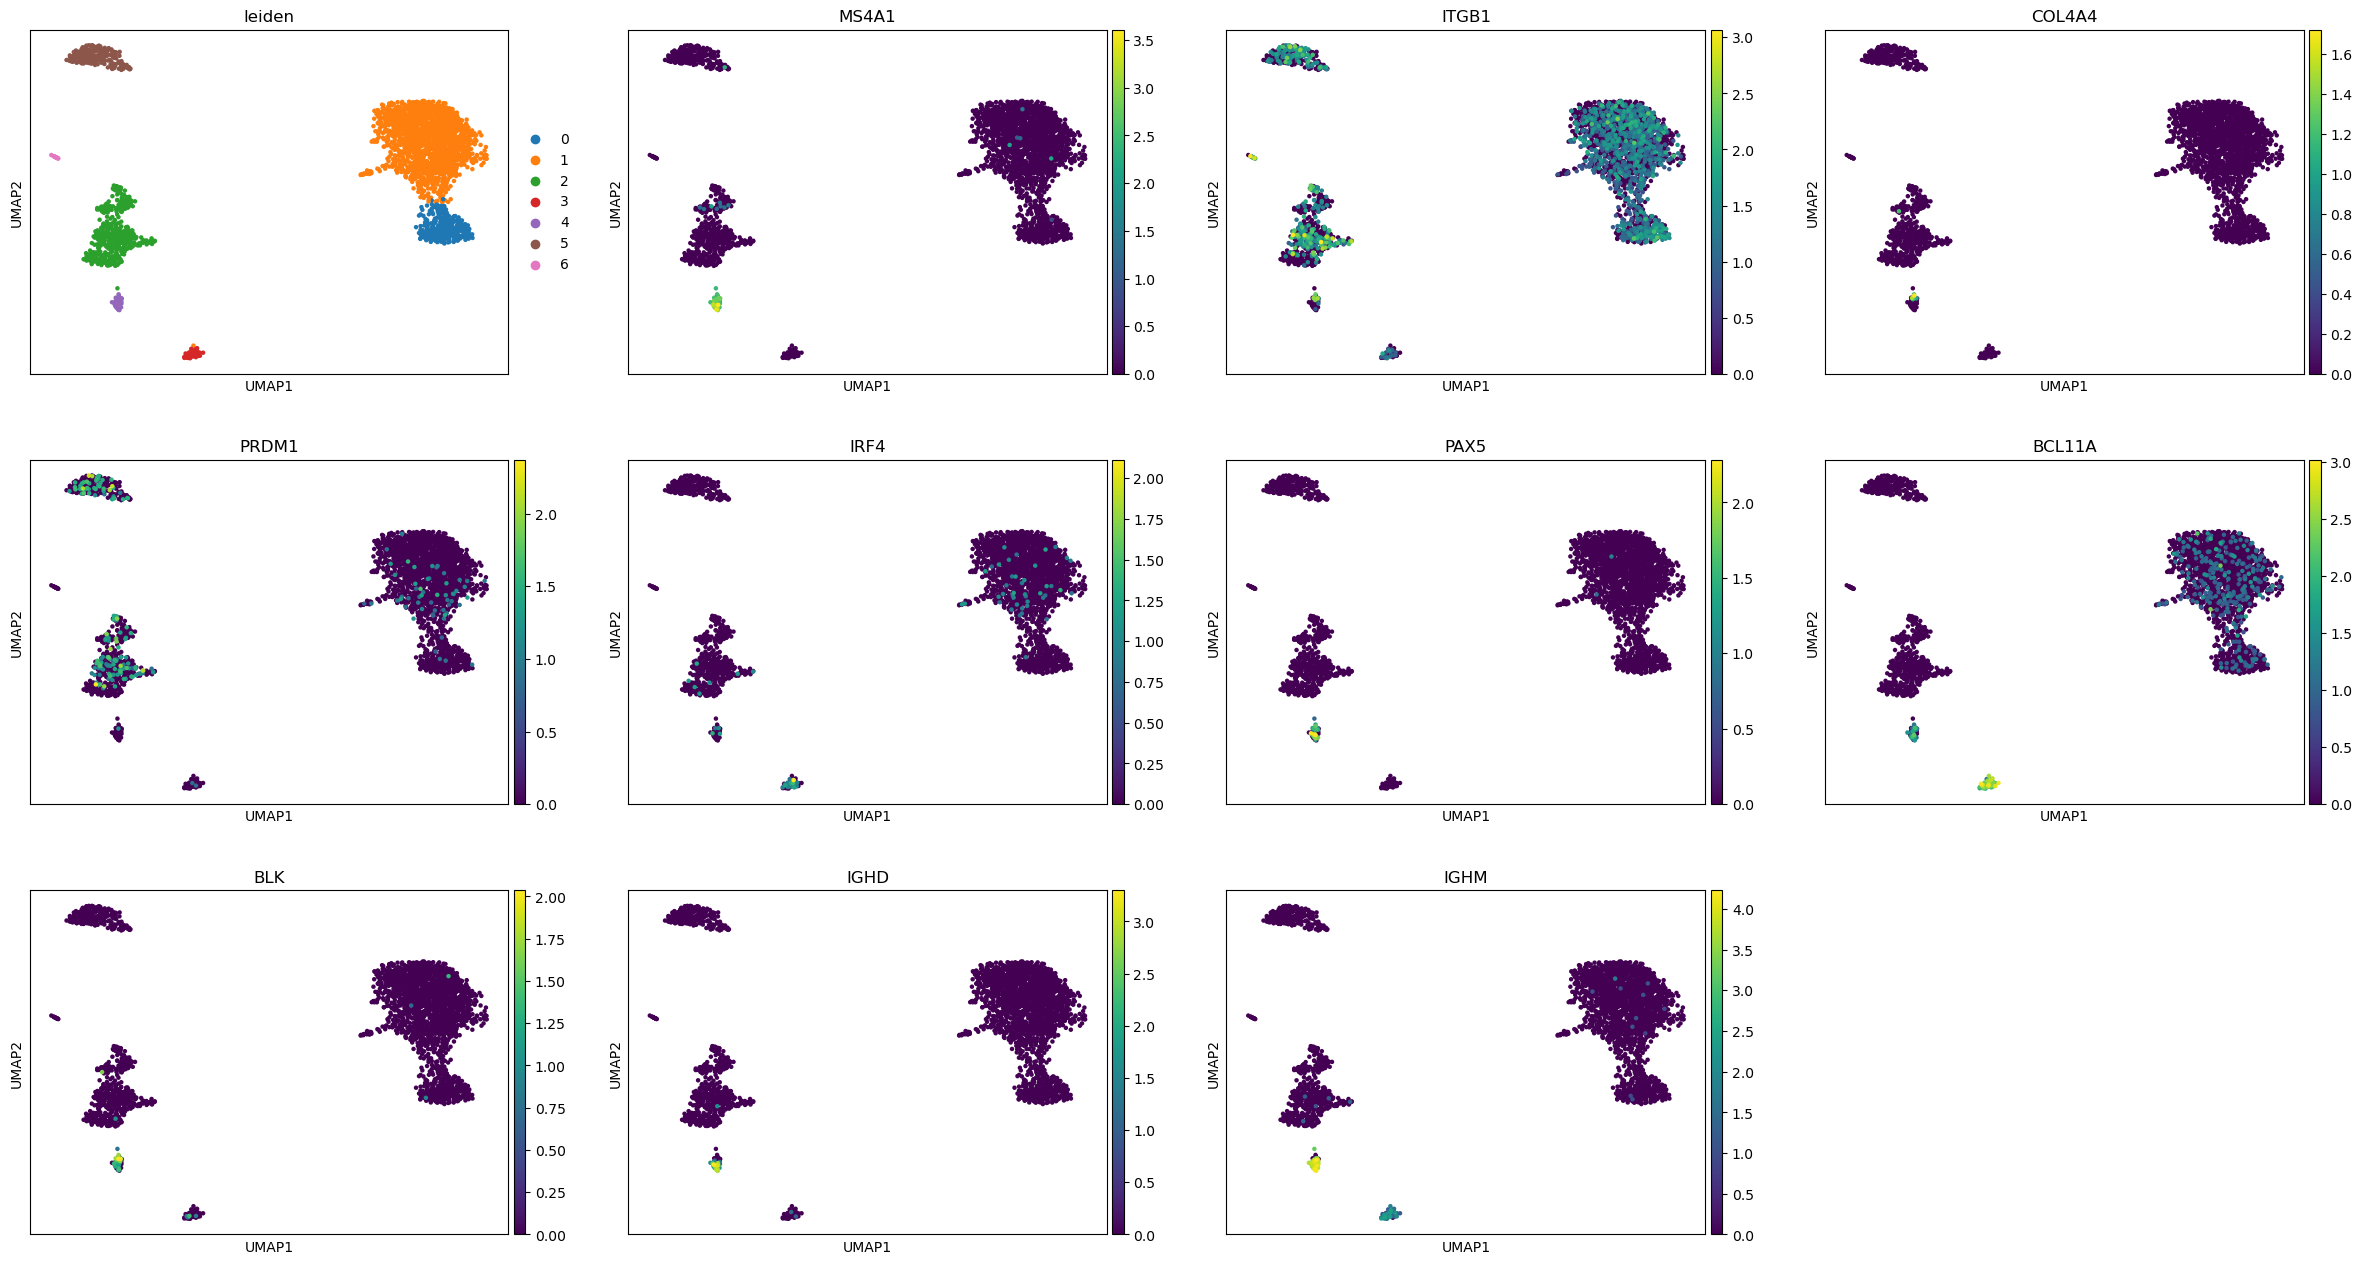

In [22]:
sc.pl.umap(adata, color =  ['leiden'] +marker_genes['B cells'])

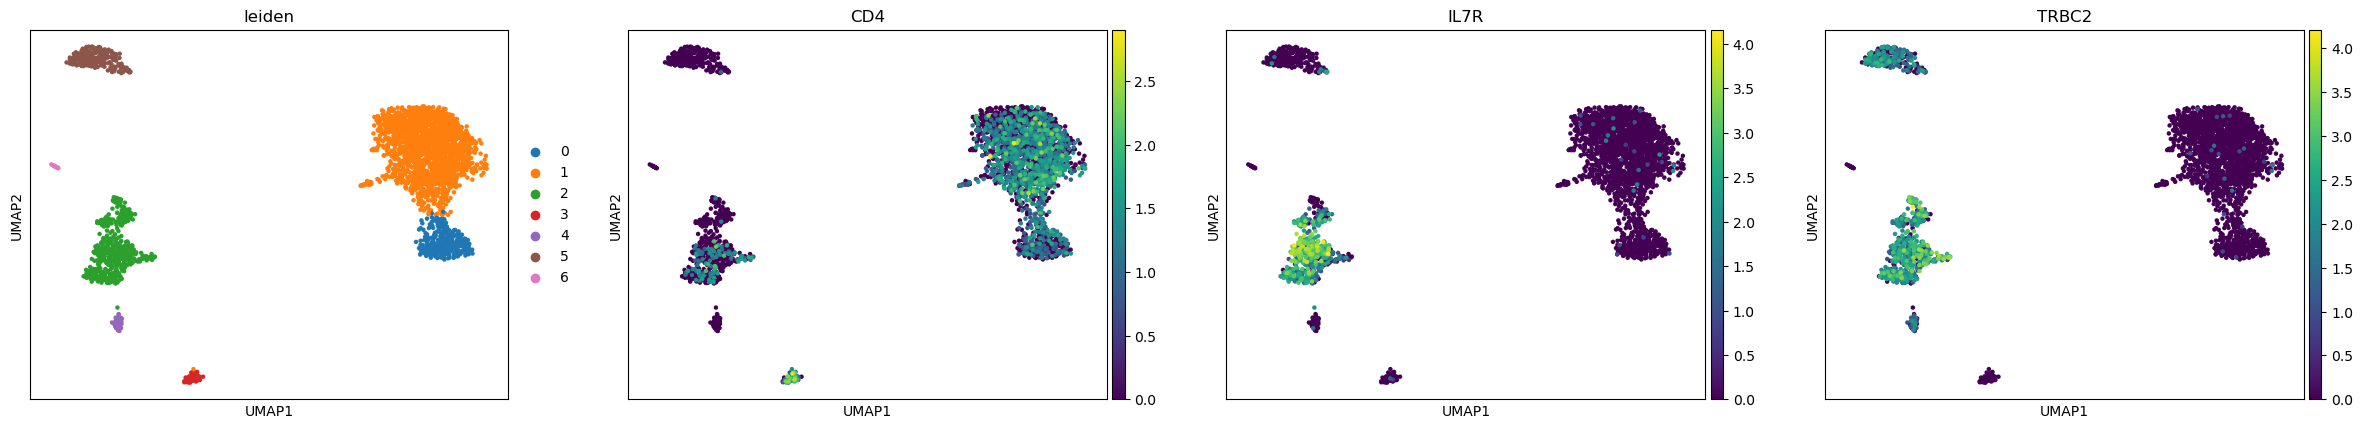

In [23]:
sc.pl.umap(adata, color =  ['leiden'] +marker_genes["CD4+ T"])

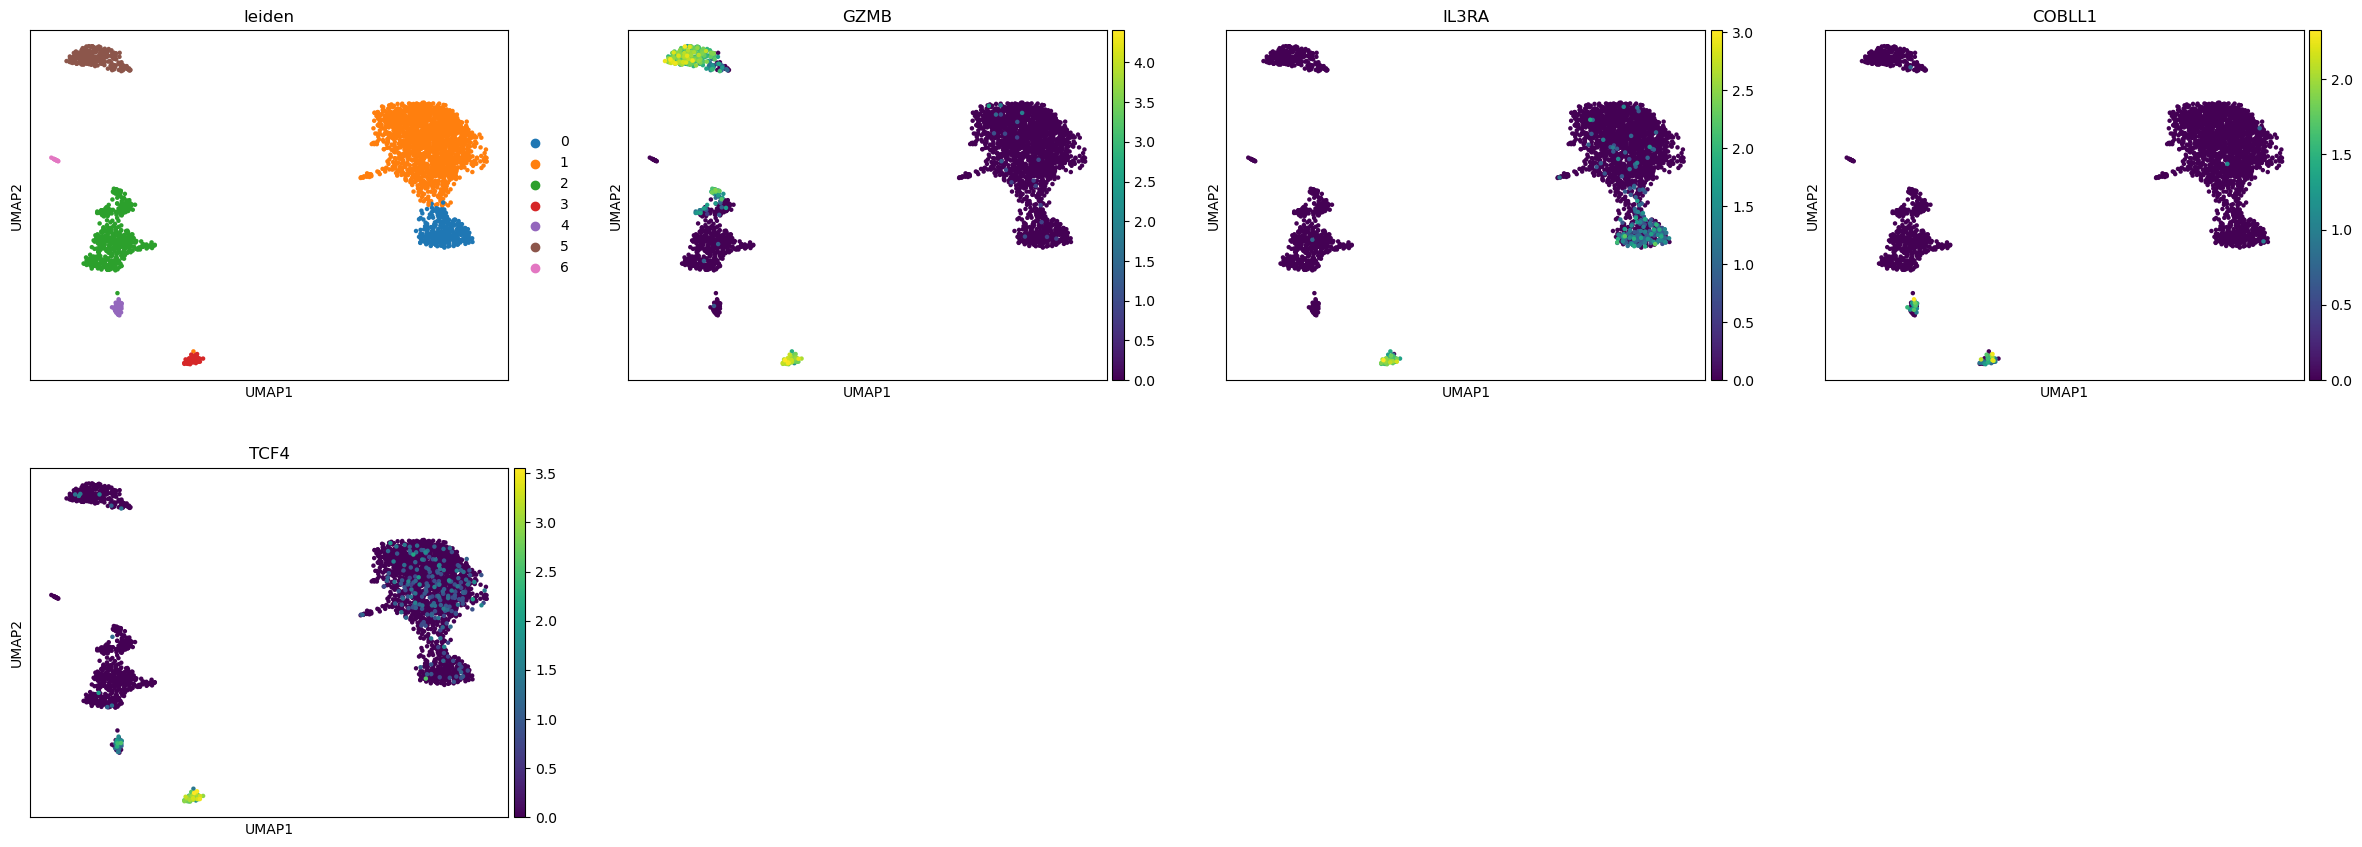

In [24]:
sc.pl.umap(adata, color =  ['leiden'] +marker_genes["pDC"])

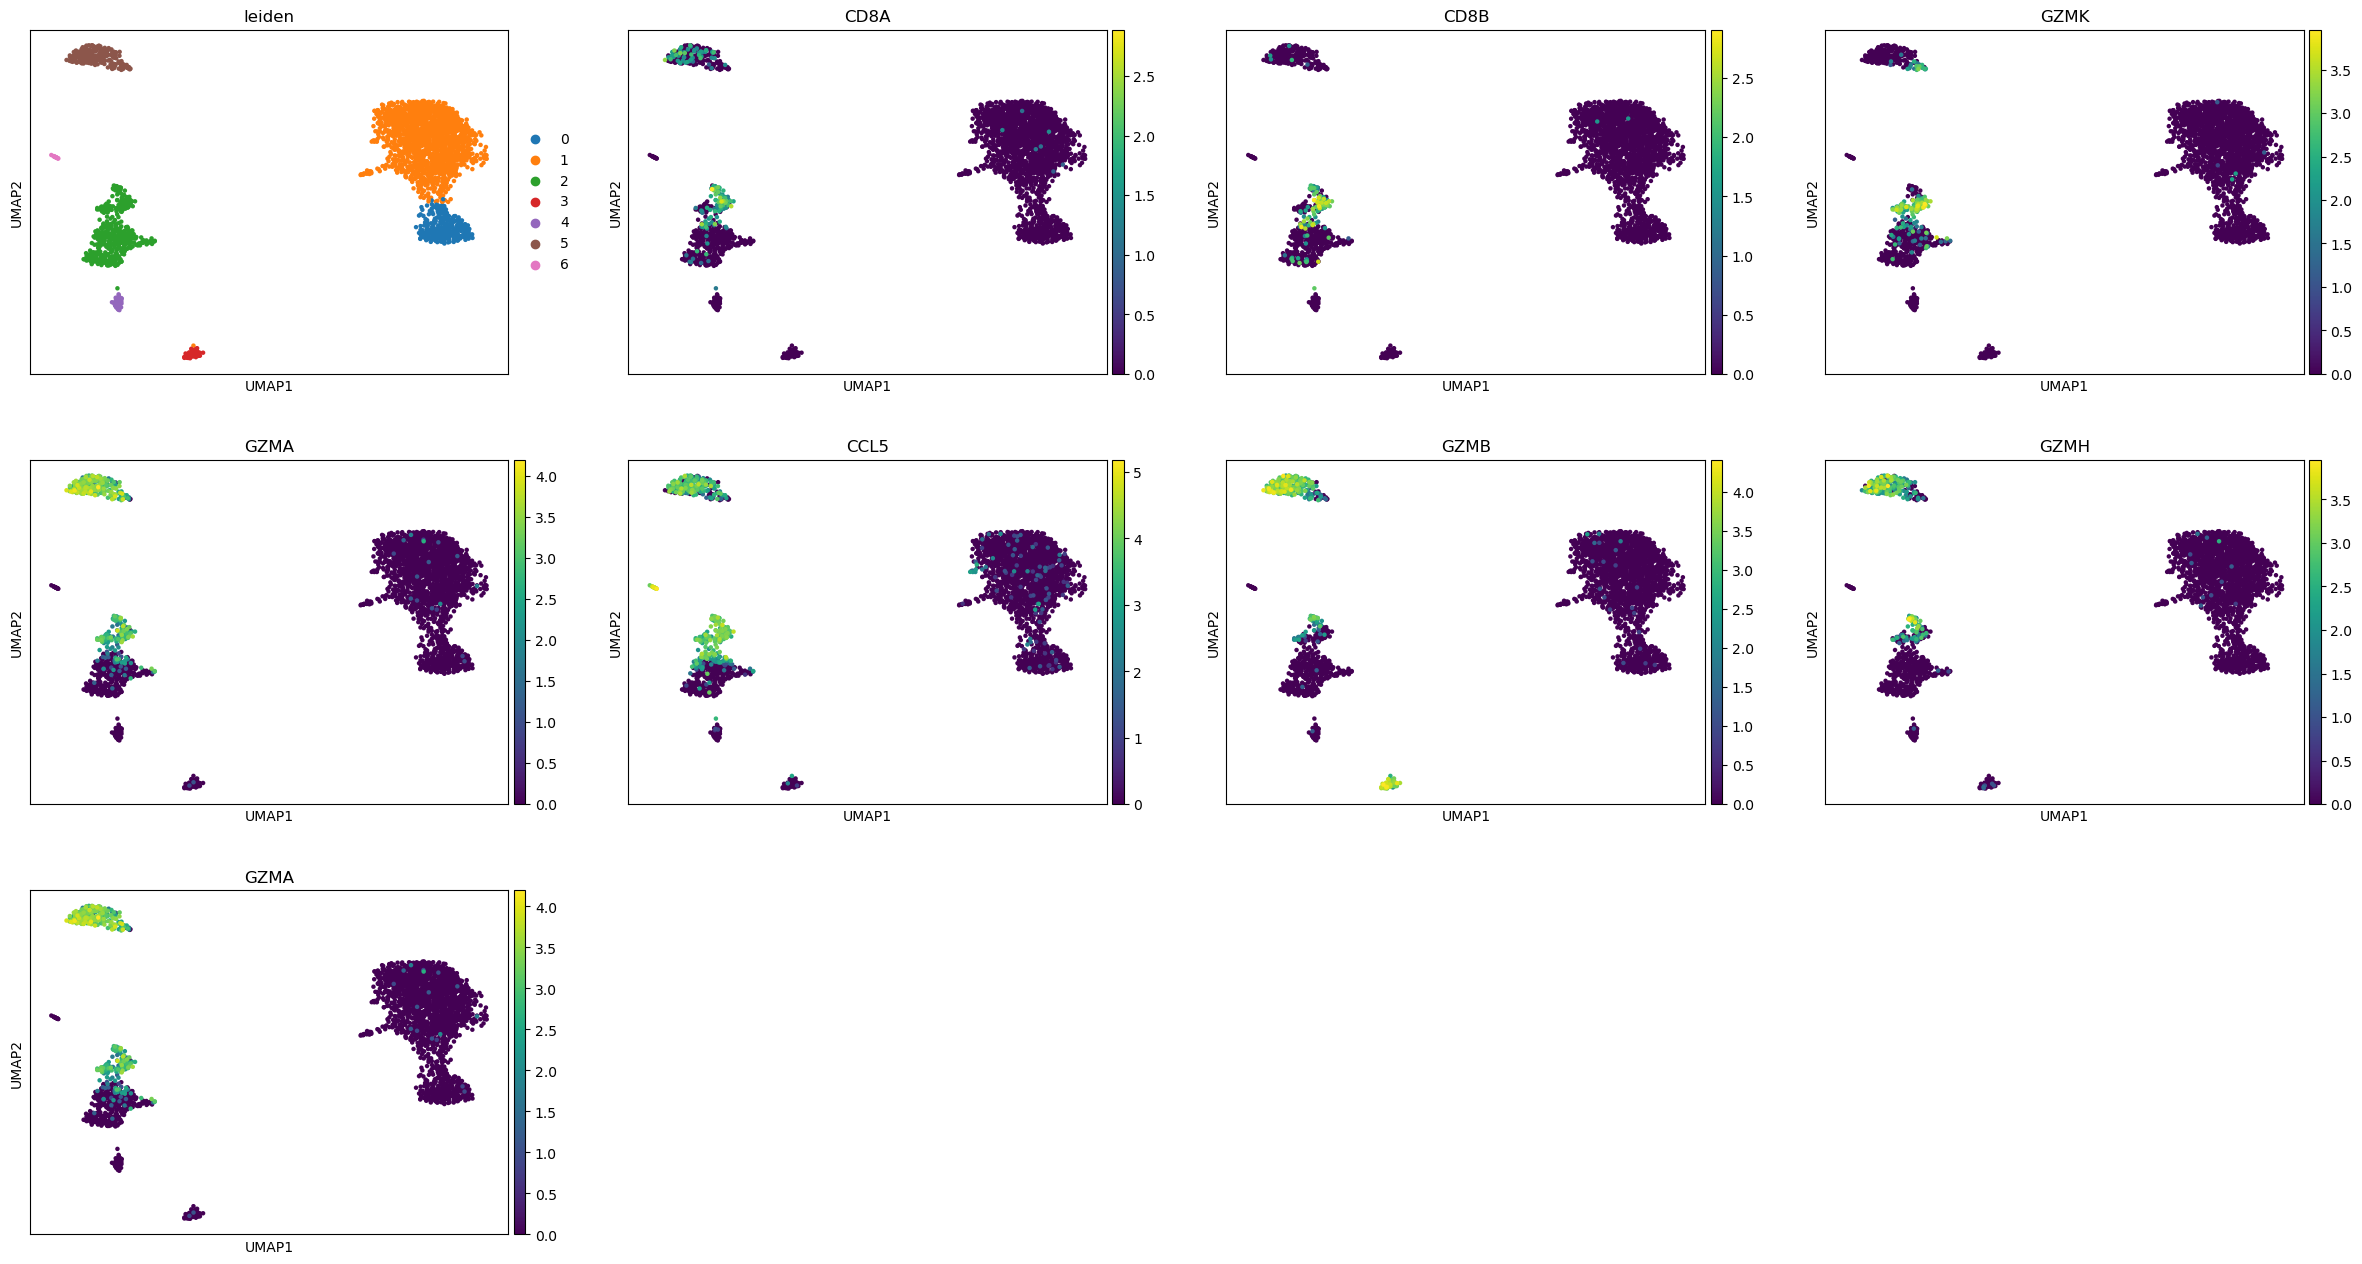

In [25]:
sc.pl.umap(adata, color =  ['leiden'] +marker_genes["CD8+ T"])

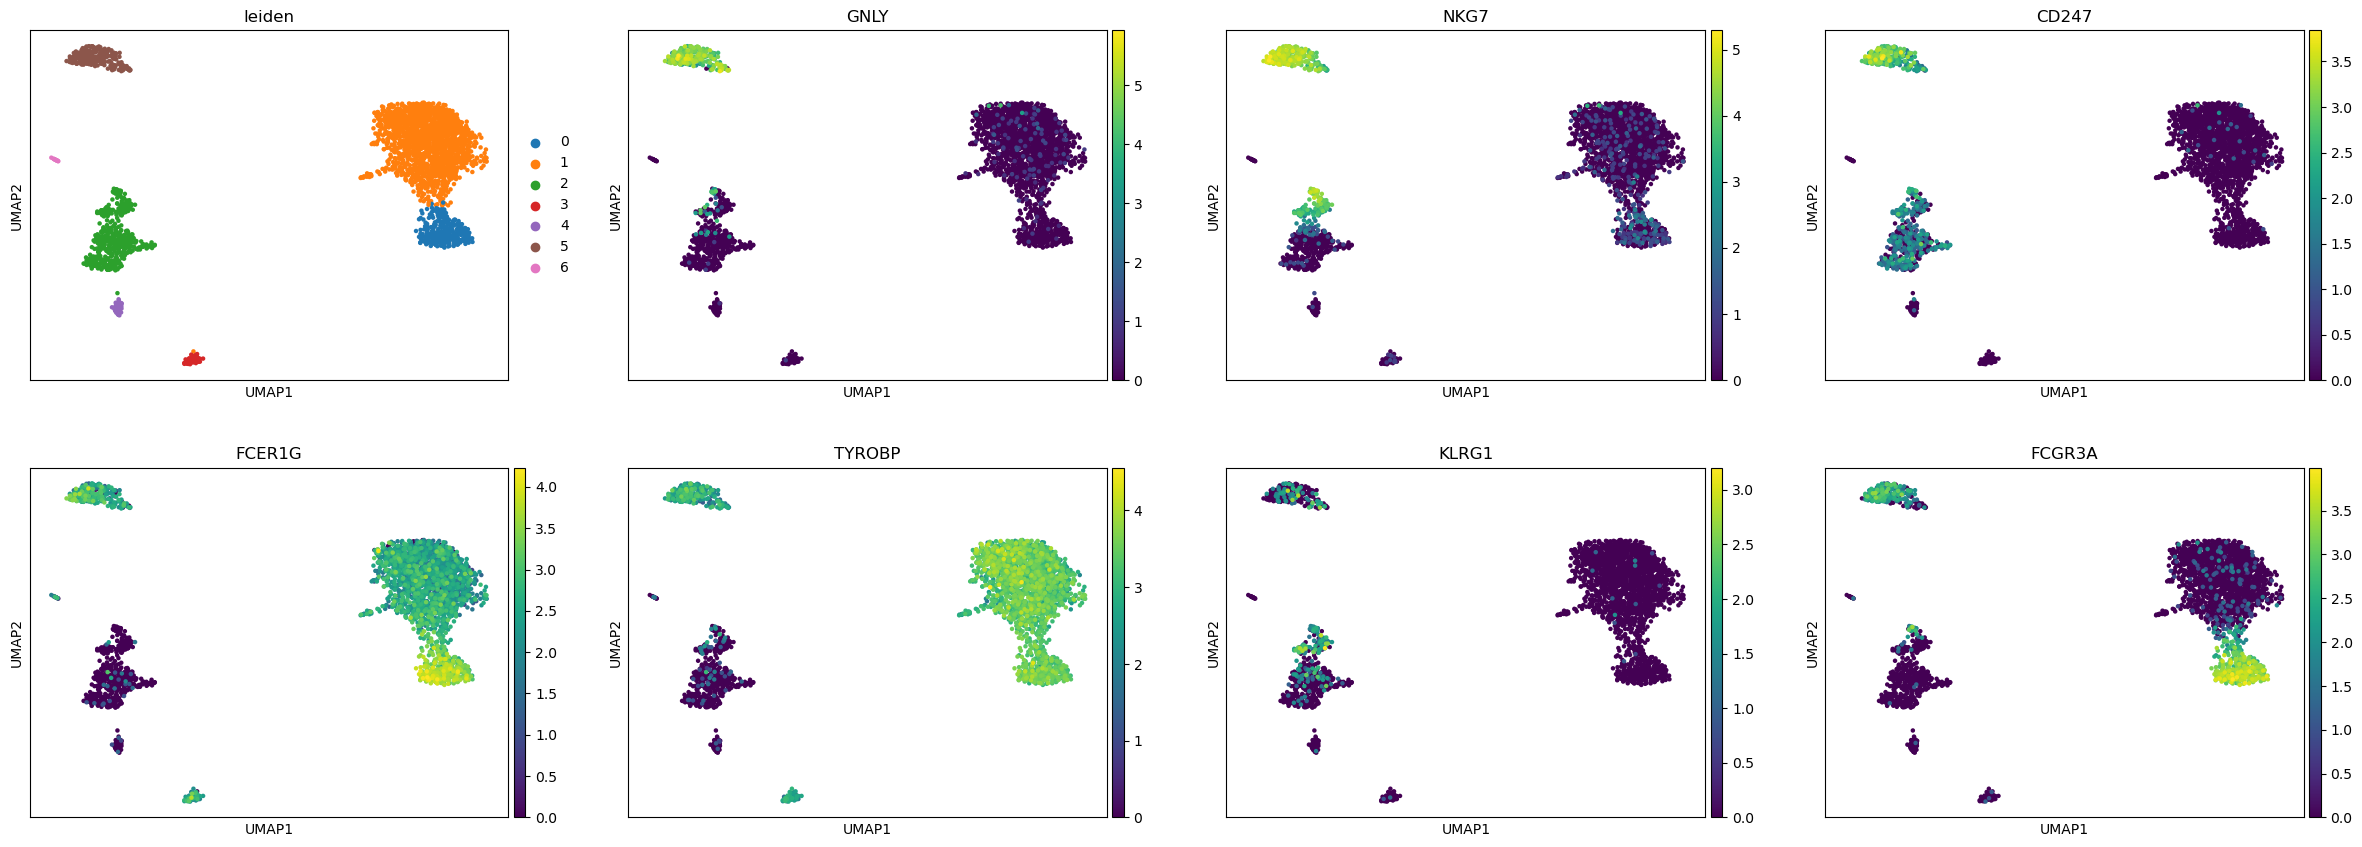

In [26]:
sc.pl.umap(adata, color =  ['leiden'] +marker_genes["NK"])

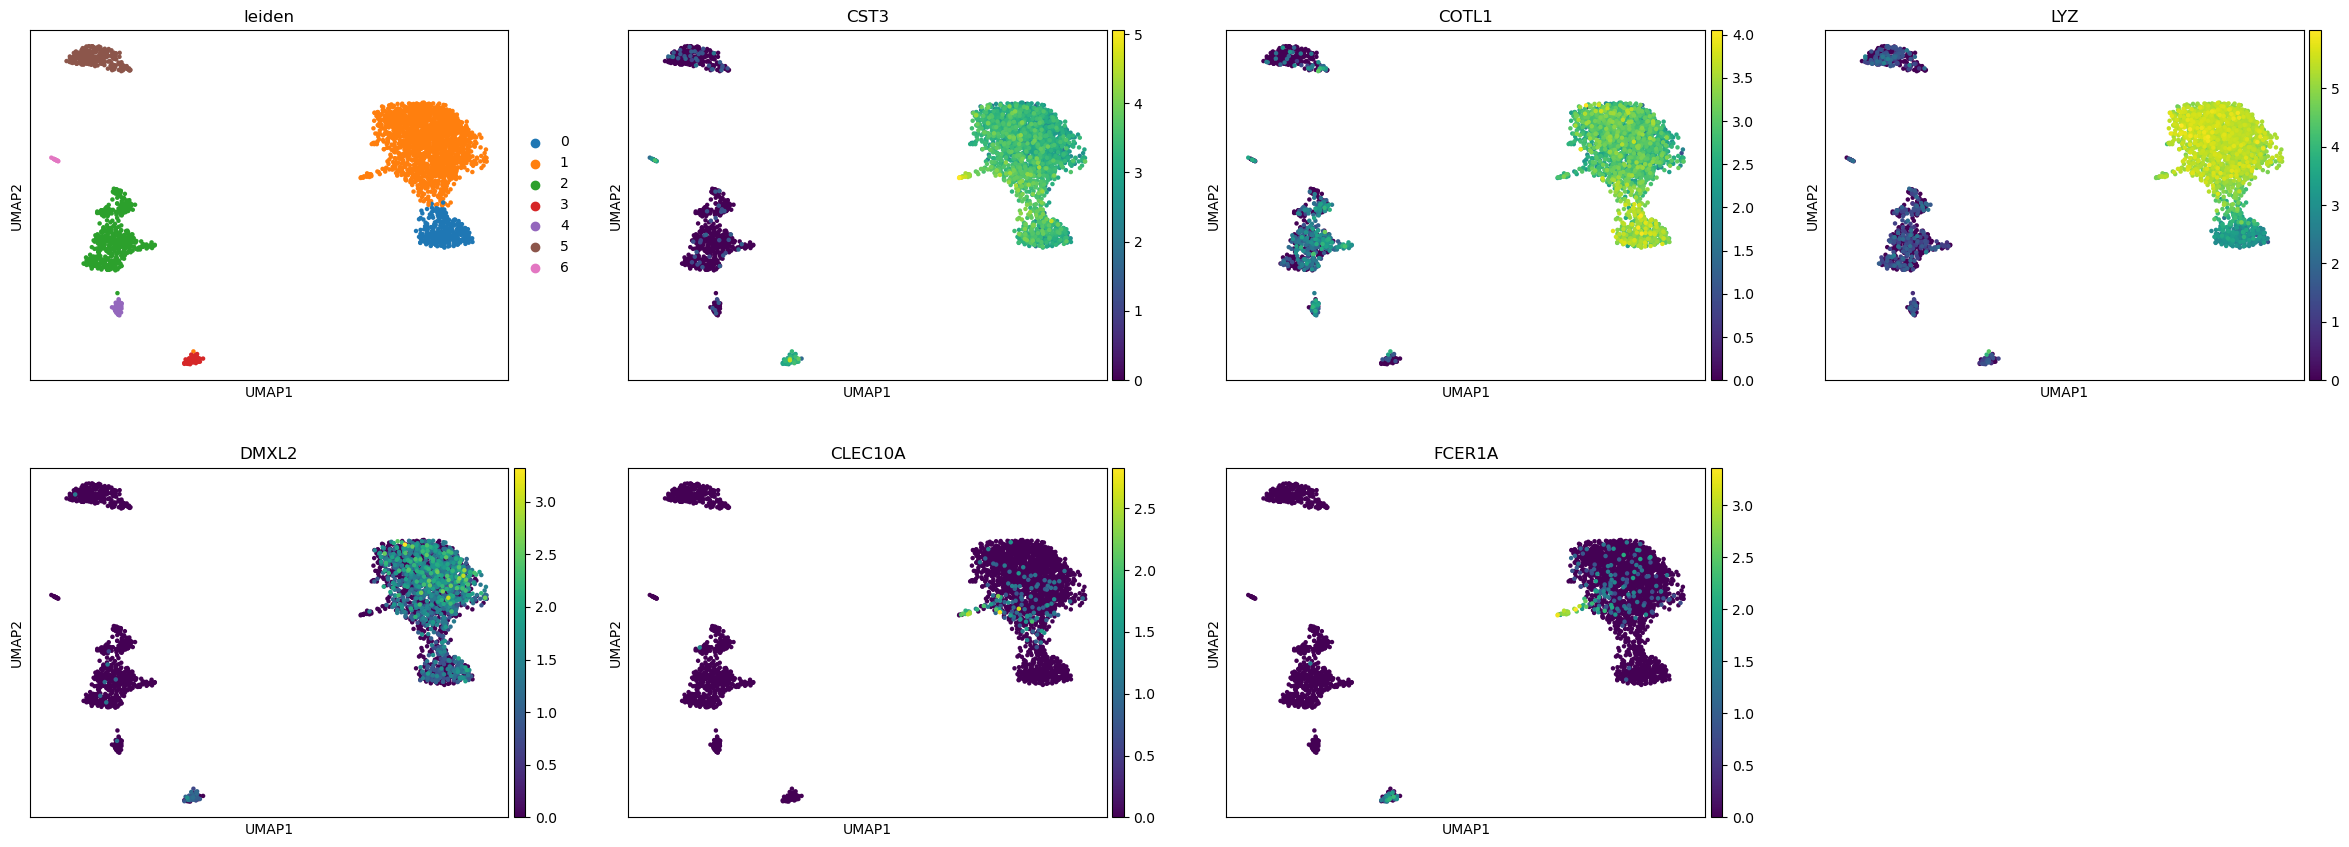

In [27]:
sc.pl.umap(adata, color =  ['leiden'] +marker_genes["cDC2"])

In [28]:
manual_celltype_mapper = {'0': 'CD16+ Monocytes', '1': 'CD14+ Monocytes', '2': 'T cells', '3': 'pDC', '4': 'B cells', '5': 'NK cells', '6': 'cDC2'}

In [29]:
adata.obs['manual_celltype_labels'] =adata.obs['leiden'].map(manual_celltype_mapper)

Based on our observations on the plots and some knowlegde on the celltypes, we could for example arrive at the following celltype assignments. We plot them side-by-side with the original leiden clustering.

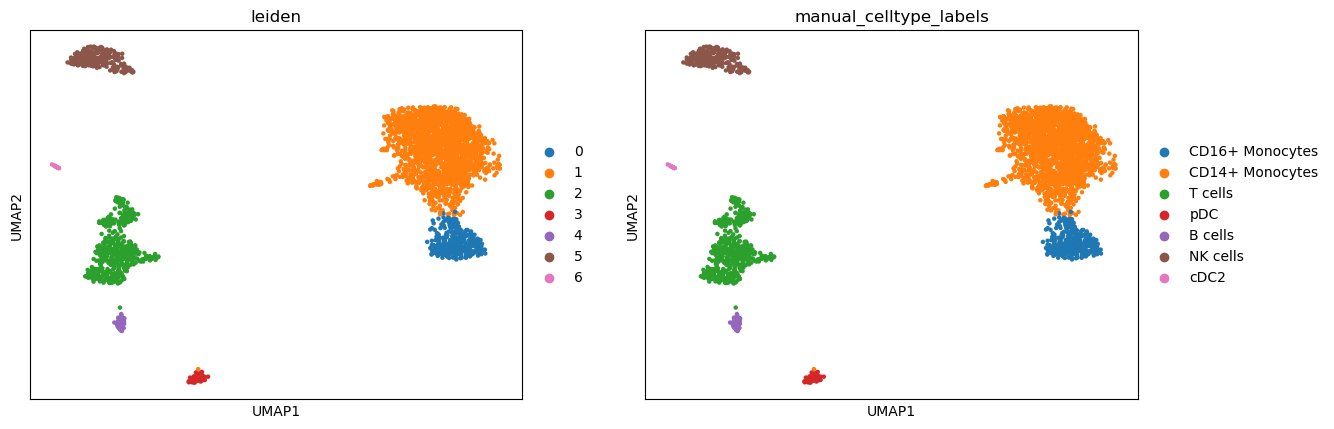

In [30]:
sc.pl.umap(adata, color =  ['leiden'] +['manual_celltype_labels'])

## 8 — Differential Expression

We can also identify new marker genes or find out how our clusters are different from each other by running a differential test. Here we use the Wilcoxon rank sum test (Mann-Withney U) to find the differences. Note that this is statistically not very robust, because the single cells are from the same biological sample and therefore are correlated with each other. However most statistical tests assume independence of the measurements. Nonetheless, the test can give us a general idea of what we are looking us, even if the statistical significance values are not correctly computed.

Perform a differential expression test to identify marker genes for each cell type (or a comparison of interest).

> See: https://www.sc-best-practices.org/conditions/differential_gene_expression.html



In [31]:

sc.tl.rank_genes_groups(adata, groupby="manual_celltype_labels", method="wilcoxon")
sc.tl.dendrogram(adata, groupby = 'manual_celltype_labels')

On the dotplot, wer can see that there are distinct groups of genes which are very prominent in one of the celltypes we computed, but not in others. These are additional characteristic genes for these clusters and can help us correct or refine the annotation we made previously.

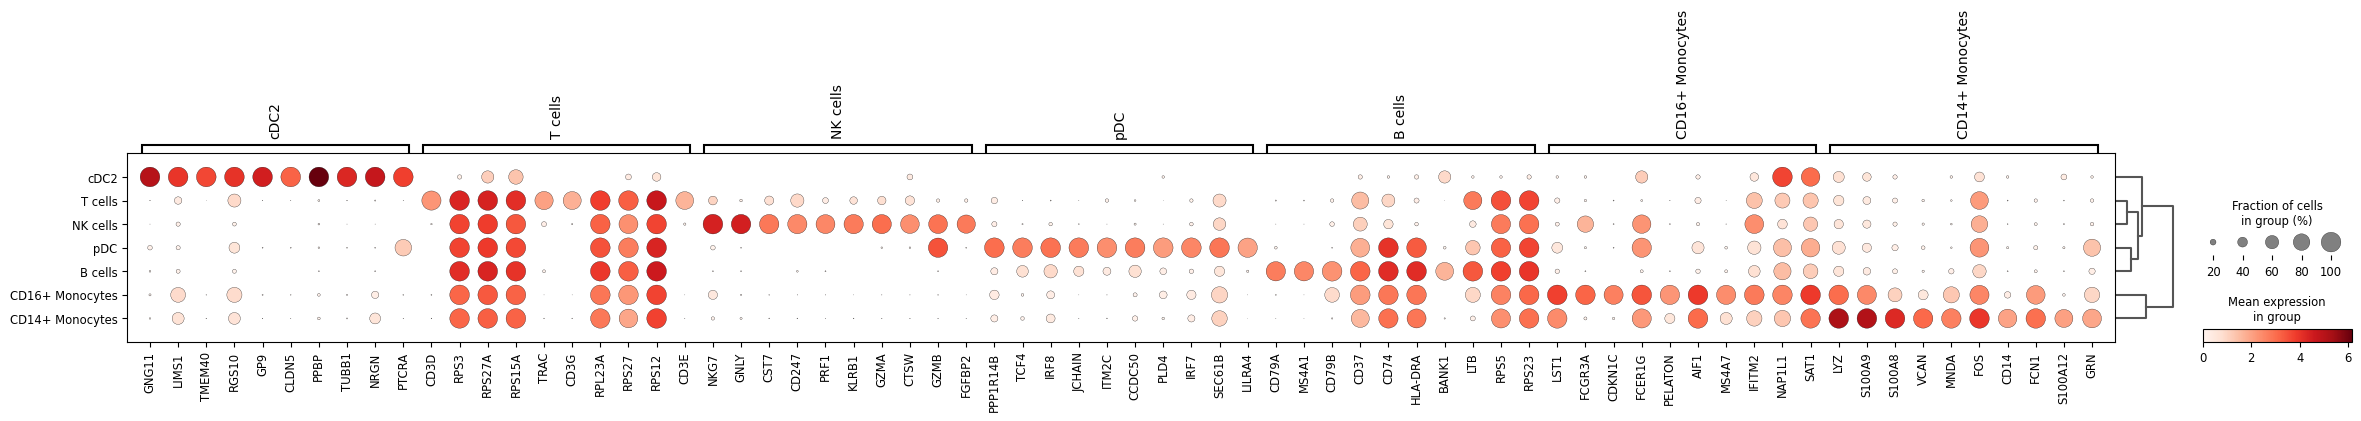

In [32]:
sc.pl.rank_genes_groups_dotplot(adata)

We can obtain the list of cluster differential genes by using a specific function provided by scanpy. Here, we obtain the results for all celltypes we anotated as a pandas dataframe.
You can specify individual celltypes by the group argument.

In [33]:
de_genes = sc.get.rank_genes_groups_df(adata, group = adata.obs.manual_celltype_labels.unique())

In [34]:
#Save your DE results as a CSV file (e.g., `de_results.csv`).
import os.path as op
import os
results_dir = './results'
os.makedirs(results_dir, exist_ok=True)
de_genes.to_csv(op.join(results_dir, 'de_results.tsv'), sep='\t')

In [35]:
# finally we save our quality controlled and annotated object in a new anndata object.
adata.write_h5ad(op.join(results_dir, 'adata_qc.h5ad'))

## 10 -- HINTS and functions to use.
These are important functions on the scanpy tutorials. It is helpful to have a rough idea of what they do.
> **Hints:**  
> - `sc.pp.log1p()` — log-transform the data
> - `sc.get.rank_genes_groups_df()` — export results as a DataFrame  
> - Save the raw (normalized but un-scaled) counts with `adata.raw = adata` before scaling
> - `sc.pl.dotplot()` or `sc.pl.violin()` — show expression across clusters
> - `sc.pp.filter_cells()` — filter by minimum/maximum counts or genes  
> - `sc.pp.scale()` — zero-mean, unit-variance scaling (optional but common before PCA)
> - `sc.tl.rank_genes_groups(adata, groupby='manual_celltype_labels', method='wilcoxon')` — Wilcoxon rank-sum test  
> - `sc.pl.rank_genes_groups()` — visualize top DE genes  
> - `sc.pp.filter_genes()` — filter by minimum number of cells
> - `sc.pp.highly_variable_genes()` — find genes that vary across cells  

> - `sc.pp.pca()` — principal component analysis (use `use_highly_variable=True`)  
> - `sc.pp.neighbors()` — construct the *k*-nearest-neighbor graph  
> - `sc.tl.umap()` — compute the UMAP embedding  
> - `sc.tl.leiden()` — Leiden community detection (pass a `resolution` parameter to tune granularity)
> - `sc.pp.normalize_total()` — normalize each cell to a target sum (typically 10 000)  

> - Use `sc.pp.calculate_qc_metrics()`.
> - `sc.pl.umap(adata, color=[...])` — color UMAP by gene expression  
> - `sc.tl.rank_genes_groups()` with `sc.pl.rank_genes_groups()`
> -  Use `adata.write_h5ad('<your_filename>_qc.h5ad')`.
> -  adata.obs.to_csv('obs.tsv', sep='\t')`.